In [3]:
include("CRD_STA.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using ProgressMeter
using DelimitedFiles
using PyCall
using SparseArrays
using HDF5

In [ ]:
for Tw = 0.8 : 0.1 : 1.2
    for omega = -0.1 : -0.01 : -0.15
        original = read("output_GR_data_$omega _$Tw _0.3.dat",String)
        header = "Zone T = \"Tw=$Tw, Ma=0.6, omega=$omega\""
        open("output_GR_data_$omega _$Tw _0.6.dat", "w") do io
            write(io,header * "\n" * original)
        end
    end
end

In [ ]:
for omega = -0.22

    for Tw = 1
        N_cheb = 99
        Mr = 0.3
        gamma = 1.4
        sigma = 0.72
        be_end = 0.2
        be_step = 0.001
        R_end = 100
        R_step = 0.1
        be_start = -0.16
        Ro = 1
        Co = 0
        Ma = Mr/R_end
        global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
        H,T = T_ca(Mr,f,q,w0,gamma,Tw)
        F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
        lam = - (2/3) * T
        kappa = (1/sigma) * T
        global GR = 0
        global initial_i= []
        global initial_r= []
        global tempvec_i = []
        global tempvec_r = []
        global guess = 0
        writedlm("output_eig.dat",initial_r)
        writedlm("output_GR_$omega _$Tw _$Mr.dat",initial_r)
        writedlm("output_GR_data_$omega _$Tw _$Mr.dat",initial_r)
        for be = be_start : 1 * be_step : be_end
            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R_end,Ma,omega,be,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec1 = iar(nep,σ = 0.1 , neigs = 1 ,maxit = 500,tol=1e-10)
            eigval = conj(eigval[1])
            tempvec_i = [tempvec_i;imag(eigval[1])]
            tempvec_r = [tempvec_r;real(eigval[1])]
            open("output_eig.dat", "a") do io
                write(io,"R = $R_end,be = $be,eig = $eigval,1\n")
            end
            if length(tempvec_i) > 3 && tempvec_i[end - 1, 1] * tempvec_i[end , 1] < 0 
                initial_i = [omega R_end be imag(eigval[1])]
                initial_r = [omega R_end be real(eigval[1])]
                global beta = initial_i[end,3]
                guess = initial_r[end,4] - im * initial_i[end,4]
                tempvec_i = []
                tempvec_r = []
                break
            end
        end
        for be = beta : 1 * be_step : be_end
            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R_end,Ma,omega,be,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec1 = iar(nep,σ = guess , neigs = 1 ,maxit = 500,tol=1e-10)
            eigval = conj(eigval[1])
            tempvec_i = [tempvec_i;imag(eigval[1])]
            tempvec_r = [tempvec_r;real(eigval[1])]
            if  length(tempvec_i) > 10 && tempvec_r[end - 1 ,1] > tempvec_r[end ,1] && tempvec_i[end, 1] < 0
                global type1max = tempvec_i[end - 1,1]
                global be1 = be

                break
            else
                guess = tempvec_r[end ,1] - im * tempvec_i[end, 1]
            end
            open("output_eig.dat", "a") do io
                write(io,"R = $R_end,be = $be,eig = $eigval,2\n")
            end
        end
            global tempvec_i = [0]
            global tempvec_r = [0.7]
        for be = 0.2  : -1 * be_step : -0.1
            guess = tempvec_r[end,1] - im * tempvec_i[end, 1]
            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R_end,Ma,omega,be,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec1 = iar(nep,σ = guess , neigs = 1 ,maxit = 500,tol=1e-10)
            eigval = conj(eigval[1])
            global tempvec_i = [tempvec_i;imag(eigval[1])]
            global tempvec_r = [tempvec_r;real(eigval[1])]
            open("output_eig.dat", "a") do io
                write(io,"R = $R_end,be = $be,eig = $eigval,3\n")
            end
            if  length(tempvec_i) > 10 && tempvec_r[end - 1 ,1] < tempvec_r[end ,1] && tempvec_i[end, 1] < 0
                global type2max = tempvec_i[end - 1,1]
                global be2 = be
                break
            end
        end
        if  type2max < type1max
            global beta = be2
        else
            global beta = be2
        end
    end
end
#         for R = R_start  : R_step : R_end
#             Ma = Mr/R
#             A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,beta,N_cheb,1,0)
#             nep = PEP([A0,A1,A2]); 
#             eigval_2,eigvec = iar(nep , σ = 0.4 - im * total_i[end,4] , neigs = 2 ,maxit = 500,tol=1e-10)
#             eigval_2 = conj(eigval_2)
#             index = findmin(imag(eigval_2))
#             GR_temp = imag(eigval_2[index[2]]) * R_step
#             global GR = GR + abs(GR_temp)
#             open("output_GR_$omega _$Tw _$Mr.dat", "a") do io
#             write(io,"R = $R , eigmode2 = $eigval_2 , GR = $GR\n")
#             end
#             open("output_GR_data_$omega _$Tw _$Mr.dat", "a") do io
#             write(io,"$beta\t$R\t$GR\n")
#             end
#             total_i = [omega R beta imag(eigval_2[index[2]])]
#             total_r = [omega R beta real(eigval_2[index[2]])]
#         end
#     end
# end


In [5]:
Tw = 1
N_cheb = 99
Mr = 0.3
gamma = 1.4
sigma = 0.72
be_step = 0.001
Ro = 1
Co = 0
R = 100
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T
global data_total = [0 0 0]
for omega = -0.1
        temp_i = [0]
        temp_r = [0.8]
        guess = temp_r[end] - im * temp_i[end]
        data = [0 0 0]
        diff = []
        diff2 = 0
        writedlm("output_eig.dat",data)
        be0 = 1.2 * omega + 0.2
        for be = be0 :  -1* be_step : -0.2
        
            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval2,eigvec2 = iar(nep,σ = guess  ,neigs = 1 ,maxit = 500,tol=1e-10)
            eigval2 = conj(eigval2)
            temp_i = [temp_i;imag(eigval2[1])]
            temp_r = [temp_r;real(eigval2[1])]
            if temp_i[end - 1] * temp_i[end] < 0 && abs(temp_i[end]) < 0.01
                guess = temp_r[end] - im * temp_i[end]
                data  = [data ; [omega be eigval2[1]]]
                mode = 1
            elseif guess != 0.8
                guess = temp_r[end] - im * temp_i[end]
                data = [data ; [omega be eigval2[1]]]
                mode = 1
            else
                mode = 0
            end
            if length(data[:,1]) > 10
                diff2 = diff2_fourth(imag(data[2:end,3]),-be_step)
                diff2 = diff2[end,1]
                diff = [diff;diff2]
            end
            if length(diff) > 2 && diff[end-1] < 0 && diff[end] > 0
                data1 = data[1:end-1,:]
                break
            end
            open("output_eig.dat", "a") do io
                write(io,"omega = $omega be = $be,eig2 = $eigval2,diff=$diff2\n")
            end
        end
    temp_i = [0]
    temp_r = [0.1]
    guess = temp_r[end] - im * temp_i[end]
    data2 = [0 0 0]
    diff = []
    diff2 = 0
    data = [0 0 0]
    be1 = 1.5 * omega + 0.04
    # for be = be1 :  1* be_step : 0.5
        
    #     A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
    #     nep = PEP([A0,A1,A2]); 
    #     eigval2,eigvec2 = iar(nep,σ = guess  ,neigs = 1 ,maxit = 500,tol=1e-10)
    #     eigval2 = conj(eigval2)
    #     temp_i = [temp_i;imag(eigval2[1])]
    #     temp_r = [temp_r;real(eigval2[1])]
    #     if length(temp_i) > 3 &&  temp_i[end] * temp_i[end-1] < 0 && abs(temp_i[end]) < 0.03
    #         # temp_i[end - 2] < 0 && temp_i[end-2] < 0 temp_i[end] < 0 && temp_i[end-2]>temp_i[end-1]>temp_i[end]
    #         guess = temp_r[end] - im * temp_i[end]
    #         data = [data; [omega be eigval2[1]]]
    #         mode = 1
    #     elseif guess != 0.1
    #         guess = temp_r[end] - im * temp_i[end]
    #         data = [data ; [omega be eigval2[1]]]
    #         mode = 1
    #     else
    #         mode = 0
    #     end
    #     if length(data[:,1]) > 10
    #         diff2 = diff2_fourth(imag(data[2:end,3]),-be_step)
    #         diff2 = diff2[end,1]
    #         diff = [diff;diff2]
    #     end
    #     if length(diff) > 2 && diff[end-1] < 0 && diff[end] > 0 
    #         data2 = data[1:end-1,:]
    #         break
    #     end
    #     open("output_eig.dat", "a") do io
    #         write(io,"omega = $omega be = $be,eig2 = $eigval2,diff=$diff2\n")
    #     end
    # end
    data = [data2[2:end,:];data1[end:-1:2,:]]
    data_total = [data_total;data]
end


┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/Ha7rZ/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

InterruptException: InterruptException:

In [69]:
data_total = data_total[2:end,:]

125×3 Matrix{ComplexF64}:
 -0.14+0.0im  -0.106+0.0im  0.0626505-0.00190436im
 -0.14+0.0im  -0.105+0.0im  0.0671931-0.00617538im
 -0.14+0.0im  -0.104+0.0im  0.0717097-0.01005im
 -0.14+0.0im  -0.103+0.0im  0.0761655-0.0136077im
 -0.14+0.0im  -0.102+0.0im  0.0805422-0.0169154im
 -0.14+0.0im  -0.101+0.0im  0.0848329-0.0200264im
 -0.14+0.0im    -0.1+0.0im  0.0890368-0.0229822im
 -0.14+0.0im  -0.099+0.0im  0.0931566-0.0258186im
 -0.14+0.0im  -0.098+0.0im  0.0971951-0.0285624im
 -0.14+0.0im  -0.097+0.0im   0.101158-0.0312357im
      ⋮                     
 -0.14+0.0im    0.01+0.0im   0.786384-0.0115491im
 -0.14+0.0im   0.011+0.0im   0.788507-0.0100651im
 -0.14+0.0im   0.012+0.0im    0.79062-0.0085987im
 -0.14+0.0im   0.013+0.0im   0.792725-0.00714931im
 -0.14+0.0im   0.014+0.0im    0.79482-0.00571704im
 -0.14+0.0im   0.015+0.0im   0.796908-0.00430103im
 -0.14+0.0im   0.016+0.0im   0.798986-0.00290106im
 -0.14+0.0im   0.017+0.0im   0.801056-0.00151669im
 -0.14+0.0im   0.018+0.0im   0.803119-0.

In [35]:
data = data[2:end,:]

121×2 Matrix{ComplexF64}:
 -0.186+0.0im   -0.0719941-0.0265475im
 -0.185+0.0im   -0.0456987-0.0230853im
 -0.184+0.0im   -0.0246436-0.0244162im
 -0.183+0.0im  -0.00768054-0.027149im
 -0.182+0.0im   0.00655954-0.0302043im
 -0.181+0.0im     0.018927-0.0332743im
  -0.18+0.0im    0.0299436-0.0362758im
 -0.179+0.0im    0.0399441-0.0391939im
 -0.178+0.0im    0.0491515-0.0420397im
 -0.177+0.0im    0.0577256-0.0448272im
       ⋮       
 -0.074+0.0im     0.121102-0.349479im
 -0.073+0.0im     0.119546-0.349945im
 -0.072+0.0im     0.118006-0.350389im
 -0.071+0.0im     0.116479-0.350813im
  -0.07+0.0im     0.114967-0.351217im
 -0.069+0.0im     0.113469-0.351602im
 -0.068+0.0im     0.111985-0.351968im
 -0.067+0.0im     0.110515-0.352317im
 -0.066+0.0im     0.109059-0.352648im

In [15]:
data = [data2[2:end,:];data1[end:-1:2,:]]

113×2 Matrix{ComplexF64}:
 -0.186+0.0im   -0.0719647-0.0265628im
 -0.185+0.0im   -0.0456394-0.0231506im
 -0.184+0.0im   -0.0246051-0.0245084im
 -0.183+0.0im  -0.00766248-0.0272502im
 -0.182+0.0im   0.00655693-0.0303092im
 -0.181+0.0im     0.018908-0.0333784im
  -0.18+0.0im    0.0299114-0.0363768im
 -0.179+0.0im    0.0399002-0.0392921im
 -0.178+0.0im    0.0490988-0.0421334im
 -0.177+0.0im    0.0576652-0.0449174im
       ⋮       
 -0.083+0.0im     0.777763-0.011158im
 -0.082+0.0im     0.780348-0.00969967im
 -0.081+0.0im     0.782915-0.00826305im
  -0.08+0.0im     0.785466-0.00684667im
 -0.079+0.0im     0.787997-0.00545135im
 -0.078+0.0im     0.790512-0.00407522im
 -0.077+0.0im     0.793011-0.00271801im
 -0.076+0.0im     0.795493-0.00137873im
 -0.075+0.0im      0.79796-5.77733e-5im

In [547]:
writedlm("GR_2.dat", [real(data2[2:end,1]) abs.(imag(data2[2:end,2]))])

In [38]:
R_step = -0.5
R = 100
writedlm("output_GR_tempfile.dat",[])
for i = 121
    writedlm("output_eig.dat",[])
    initial_eig =  data[i,2]
    initial_beta = real(data[i,1])
    guess = conj(initial_eig)
    GR = abs(imag(initial_eig)*R_step)
    GR_temp = 0
    temp_i = []
    temp_r = []
    for R  = R + R_step : R_step : 0
        Ma = Mr/R
        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,initial_beta,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep , σ = guess, neigs = 1 ,maxit = 500,tol=1e-10)
        eigval = conj(eigval)
        c = imag(eigval[1])
        d = real(eigval[1])
        GR_temp = imag(eigval[1]) * R_step
        global GR = GR + abs(GR_temp)
        temp_i = [temp_i;imag(eigval[1])]
        temp_r = [temp_r;real(eigval[1])]
        open("output_GR_tempfile.dat", "a") do io
            write(io,"$initial_beta $R $d $c\n")
        end
        open("output_eig.dat", "a") do io
            write(io,"R = $R ,beta = $initial_beta, eig = $eigval , GR = $GR\n")
        end
        guess = conj(eigval[1])
        if imag(eigval[1]) > 0 
          break
        end
        if length(temp_i) > 100 && temp_i[end - 2] > temp_i[end-1] > temp_i[end]
            break
        end
    end
end

In [32]:
total = readdlm("output_GR_type2.dat")
beta = total[1:end,1]
R = total[1:end,2]
GR = total[1:end,3]
total = [beta R GR]
sorted_data = sortslices(total, dims=1, by=x->x[1])
betanew = []
writedlm("data_new.dat",[])
for i = 2 : length(sorted_data[:,1])
    beta = sorted_data[i,1]
    R = sorted_data[i,2]
    GR = sorted_data[i,3]
    header = "Zone T = \"$beta,omega=$omega\""
    if sorted_data[i,1] == sorted_data[i-1,1]
        open("data_new.dat", "a") do io
        write(io,"$beta,$R,$GR\n")
        end
    else
        open("data_new.dat", "a") do io
            write(io,header * "\n")
            write(io,"$beta,$R,$GR\n")
        end
    end
end

In [521]:
writedlm("tempfile.dat",data)

In [16]:
GR = imag(data1[2:end,2])
GR_2 = imag(data2[2:end,2]) 
diff1_1 = diff_fourth(GR,-be_step)
diff1_2 = diff_fourth(GR_2,-be_step)
diff2_1 = diff2_fourth(GR,-be_step)
diff2_2 = diff2_fourth(GR_2,-be_step)

45-element Vector{Float64}:
 -11581.34650024053
  -4446.683654222764
  -1190.7753346435854
   -253.99857475337805
      8.81940223785259
     76.39133986498946
     84.945327095764
     74.6462376380186
     57.15171703411619
     41.94989087290615
      ⋮
   -171.86865431006308
   -167.85182527851114
   -159.56143802905072
   -147.13487415619898
   -129.3368850948893
   -107.04784919039756
    -80.37487419408397
    -49.60842829763538
    -15.029050845161152

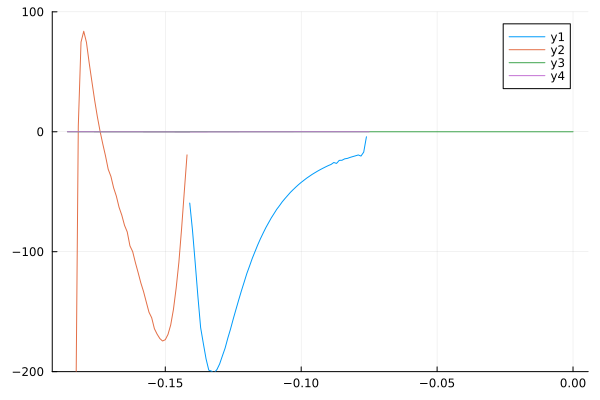

In [17]:
plot!(real(data[:,1]),imag(data[:,2]))

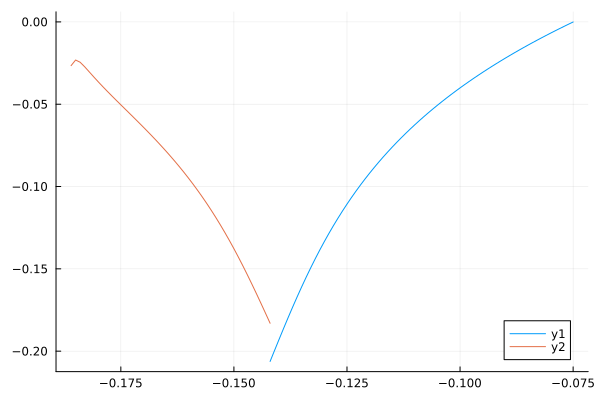

In [20]:
plot(real(data1[2:end,1]),GR)
plot!(real(data2[2:end,1]),GR_2)

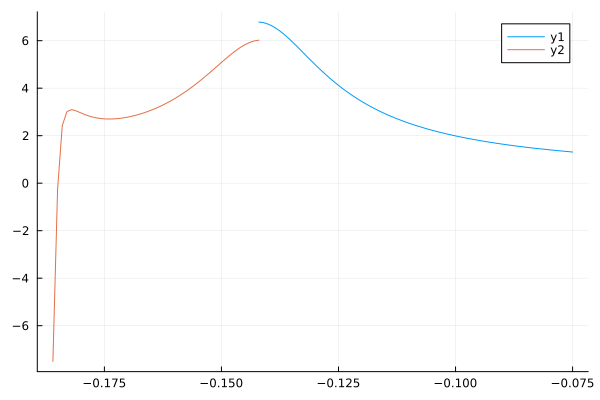

In [21]:
plot(real(data1[2:end,1]),diff1_1)
plot!(real(data2[2:end,1]),diff1_2)

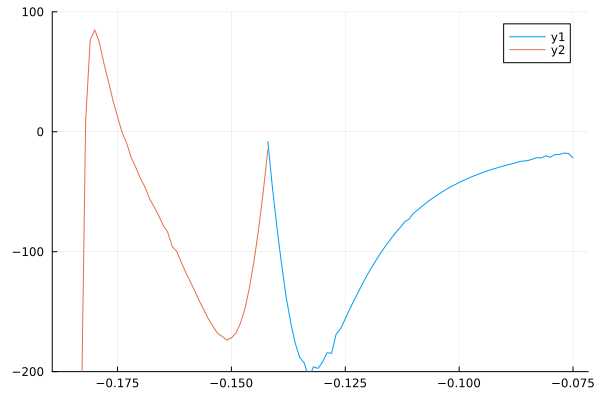

In [22]:
plot(real(data1[2:end,1]),diff2_1)
plot!(real(data2[2:end,1]),diff2_2,ylims=[-200,100])

In [4]:
function diff_fourth(y, h)
    """
    使用四阶中心差分法计算向量y的导数，并对边界使用高阶单侧差分。
    
    参数:
    y : 需要求导的函数值向量
    h : 差分步长
    
    返回:
    dy_dx : 与y等长的导数向量
    """
    n = length(y)
    dy_dx = zeros(n)
    
    # 内部点使用四阶中心差分公式
    for i in 3:n-2
        dy_dx[i] = (-y[i+2] + 8*y[i+1] - 8*y[i-1] + y[i-2]) / (12*h)
    end
    
    # 边界点使用四阶单侧差分公式
    # 第1点(向前差分)
    if n >= 5
        dy_dx[1] = (-25*y[1] + 48*y[2] - 36*y[3] + 16*y[4] - 3*y[5]) / (12*h)
    else
        dy_dx[1] = (-3*y[1] + 4*y[2] - y[3]) / (2*h) # 退化为二阶
    end
    
    # 第2点(向前差分)
    if n >= 5
        dy_dx[2] = (-3*y[1] - 10*y[2] + 18*y[3] - 6*y[4] + y[5]) / (12*h)
    else
        dy_dx[2] = (y[3] - y[1]) / (2*h) # 退化为二阶
    end
    
    # 倒数第2点(向后差分)
    if n >= 5
        dy_dx[n-1] = (-y[n-4] + 6*y[n-3] - 18*y[n-2] + 10*y[n-1] + 3*y[n]) / (12*h)
    else
        dy_dx[n-1] = (y[n] - y[n-2]) / (2*h) # 退化为二阶
    end
    
    # 最后一点(向后差分)
    if n >= 5
        dy_dx[n] = (3*y[n-4] - 16*y[n-3] + 36*y[n-2] - 48*y[n-1] + 25*y[n]) / (12*h)
    else
        dy_dx[n] = (3*y[n] - 4*y[n-1] + y[n-2]) / (2*h) # 退化为二阶
    end
    
    return dy_dx
 end


function diff2_fourth(y, h)
    """
    使用四阶中心差分法计算向量y的二阶导数，边界处理采用高阶公式。
    
    参数:
    y : 需要求导的函数值向量
    h : 差分步长
    
    返回:
    d2y_dx2 : 与y等长的二阶导数向量
    """
    n = length(y)
    d2y_dx2 = zeros(n)
    
    # 内部点使用四阶中心差分公式
    for i in 3:n-2
        d2y_dx2[i] = (-y[i+2] + 16*y[i+1] - 30*y[i] + 16*y[i-1] - y[i-2]) / (12*h^2)
    end
    
    # 边界点处理，使用更复杂的有限差分格式
    if n >= 6
        # 第1点(四阶向前差分公式)
        d2y_dx2[1] = (45*y[1] - 154*y[2] + 214*y[3] - 156*y[4] + 61*y[5] - 10*y[6]) / (12*h^2)
        
        # 第2点(四阶非对称差分公式)
        d2y_dx2[2] = (10*y[1] - 15*y[2] - 4*y[3] + 14*y[4] - 6*y[5] + y[6]) / (12*h^2)
        
        # 倒数第2点(四阶非对称差分公式)
        d2y_dx2[n-1] = (y[n-5] - 6*y[n-4] + 14*y[n-3] - 4*y[n-2] - 15*y[n-1] + 10*y[n]) / (12*h^2)
        
        # 最后一点(四阶向后差分公式)
        d2y_dx2[n] = (-10*y[n-5] + 61*y[n-4] - 156*y[n-3] + 214*y[n-2] - 154*y[n-1] + 45*y[n]) / (12*h^2)
    else
        # 退化为上面简单版本的边界处理
        # 第1点
        d2y_dx2[1] = (2*y[1] - 5*y[2] + 4*y[3] - y[4]) / (h^2)
        
        # 第2点
        d2y_dx2[2] = (y[1] - 2*y[2] + y[3]) / (h^2)
        
        # 倒数第2点
        d2y_dx2[n-1] = (y[n-2] - 2*y[n-1] + y[n]) / (h^2)
        
        # 最后一点
        d2y_dx2[n] = (2*y[n] - 5*y[n-1] + 4*y[n-2] - y[n-3]) / (h^2)
    end
    
    return d2y_dx2
 end

diff2_fourth (generic function with 1 method)